# QED-C Application-Oriented Benchmarks - IQM
The notebook demonstrates problem generation, execution, and analysis of one of the many supported application-oriented benchmarks on IQM.

Configure and run the cell below with the desired execution settings, then proceed to run the remaining cells.

In [1]:
min_qubits=2
max_qubits=4
skip_qubits=1
max_circuits=1
num_shots=100

In [2]:
import os
import time

# Initialize QED-C framework for qiskit (loads execute module)
from _common.qedc_init import qedc_benchmarks_init
qedc_benchmarks_init("qiskit")

# QED-C
from hidden_shift import hs_benchmark
from _common import metrics
import execute as ex

# Qiskit
from qiskit import QuantumCircuit, transpile

# IQM
from iqm.qiskit_iqm import IQMProvider

C:\Users\m\.conda\envs\qiskit-test-2.0\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 1: Problem Generation

Utilizing the new **_get_circuits_** flag in the architecture, we can supress execution and obtain only the problem generation components of interest.

In [3]:
circuits, metadata = hs_benchmark.get_circuits(
    min_qubits=min_qubits, 
    max_qubits=max_qubits, 
    skip_qubits=skip_qubits,
    max_circuits=max_circuits, 
    num_shots=num_shots, 
)

print(f"\nCircuits:\n{circuits}")
print(f"\nMetadata: \n{metadata}")

... execution starting at May 02, 2026 06:28:08 UTC
************
Creating [1] circuits with num_qubits = 2
************
Creating [1] circuits with num_qubits = 4

Circuits:
{'2': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x0000024E578A8610>}, '4': {'2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x0000024E57B80F50>}}

Metadata: 
{'2': {'1': {'create_time': 0.0953}}, '4': {'2': {'create_time': 0.0}}}


### The Circuits and Metadata
Note the format of the outputs:
- **circuits**: dict[str, dict[str, QuantumCircuit]] 
- **metadata**: dict[str, dict[str, dict[str, float]] | str]

Where 
1. The **first dictionary's key** represents the **number of qubits** for the group. In _metadata_, it may also serve as the subtitle.
2. The **second dictionary's key** represents the **unique identifier** for a circuit in the group. This may be a secret string for Bernstein-Vazirani, theta value for Phase-Estimation, and so on. Benchmark specific documentation can be found in our repository.
3. The **third dictionary's key** represents the **metric being stored** in _metadata_. (There is no third dictionary in _circuits_).

## Part 2: Execution

Now that we have the Qiskit circuits, we are free to run them using any execution framework that supports Qiskit!

### Preprocessing and Additional Metrics
We first convert the _circuits_ dictionary into a flat list; additionally, we choose to compute additional metrics and store them in the metrics module.

In [4]:
metadata.pop("subtitle", None)
metrics.circuit_metrics = metadata

ex.compute_all_circuit_metrics(circuits)

# Flatten for direct execution
flat_circuits = [circuits[nq][cid] for nq in circuits if isinstance(circuits[nq], dict) for cid in circuits[nq]]

print(f"Flat Circuits ({len(flat_circuits)})")
print(f"\nAdditional Metrics: \n{metrics.circuit_metrics}")

Flat Circuits (2)

Additional Metrics: 
{'2': {'1': {'create_time': 0.0953, 'depth': 8, 'size': 12, 'xi': 0.2, 'n2q': 2, 'tr_depth': 17, 'tr_size': 26, 'tr_xi': 0.083, 'tr_n2q': 2}}, '4': {'2': {'create_time': 0.0, 'depth': 8, 'size': 22, 'xi': 0.222, 'n2q': 4, 'tr_depth': 17, 'tr_size': 46, 'tr_xi': 0.095, 'tr_n2q': 4}}}


## Running Circuits

We execute the flat circuits on IQM. 

Configure the cell below with the target quantum computer and your IQM Resonance Token. 

In [5]:
iqm_server_url = "https://resonance.meetiqm.com"
quantum_computer = "sirius"
IQM_Token = os.environ.get("IQM_API_TOKEN")

In [6]:
provider = IQMProvider(iqm_server_url, quantum_computer=quantum_computer, token=IQM_Token)
backend = provider.get_backend()
backend_id = quantum_computer

transpiled_circuit = transpile(flat_circuits, backend=backend)

ts = time.time()
job = backend.run(transpiled_circuit, shots=num_shots)
result = job.result()
elapsed_time = time.time() - ts

print(f"Executed {len(flat_circuits)} circuits with {num_shots} shots in {elapsed_time:.3f} secs")

Executed 2 circuits with 100 shots in 7.812 secs


## Part 3: Analysis and Results
After executing the circuits, we can use the counts to compute the fidelities, store them, and plot the results.

### Computing Fidelities
The code below uses the counts from above and stores them in the metrics module, which can then be used to create plots. 

In [7]:
# Store execution timing metrics (elapsed_time, exec_time) for each circuit.
ex.process_circuit_results(circuits, result, elapsed_time=elapsed_time, num_shots=num_shots)

# Compute fidelity for each circuit using the benchmark's analyze method.
idx = 0
for num_qubits in circuits:
    for circuit_id in circuits[num_qubits]:
        result_obj = ex.ExecutionResult(result.get_counts(idx))
        
        _, fidelity = hs_benchmark.analyze_and_print_result(
            None, result_obj, int(num_qubits), num_shots, s_int=int(circuit_id),
        )
        
        metrics.store_metric(num_qubits, circuit_id, "fidelity", fidelity)
        idx += 1

### Visualization

Now that the fidelities are stored, we can use the metrics module to create plots. 

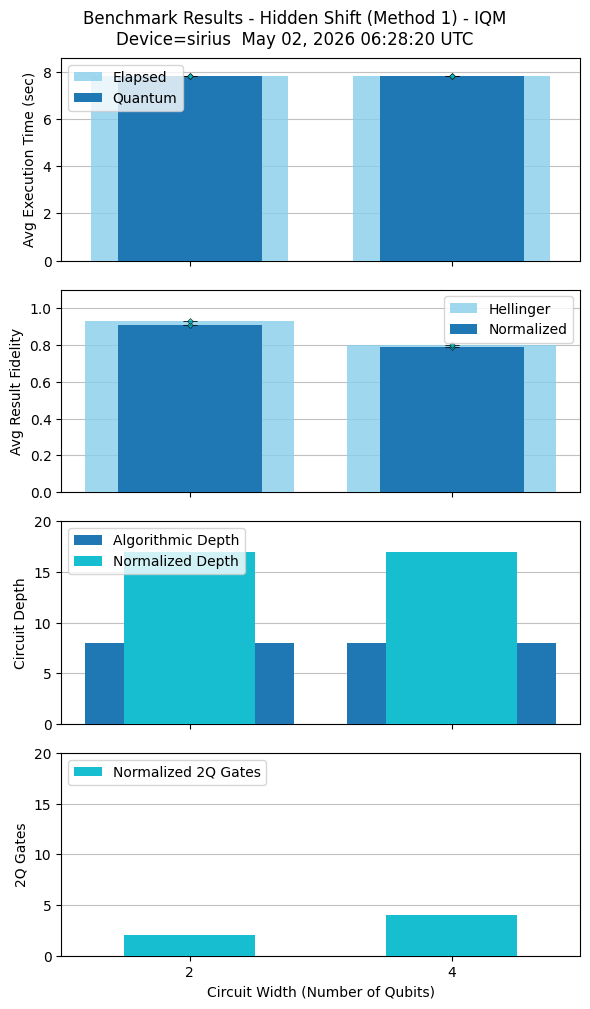

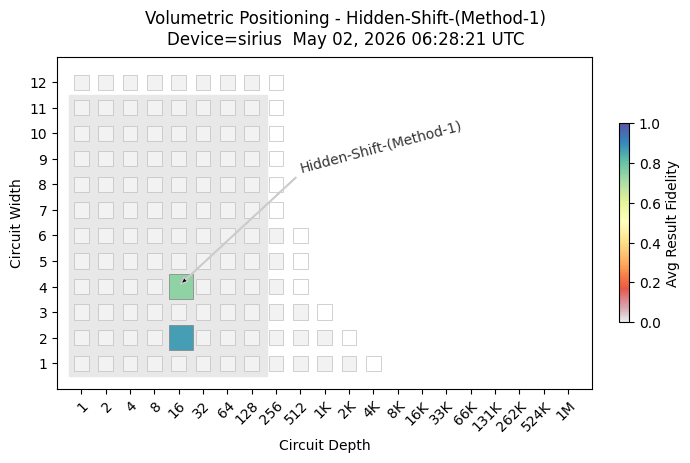

In [8]:
# Compute statistics for metrics.
metrics.aggregate_metrics()

# Set information for plot titles.
benchmark_name = "Hidden Shift"
provider_name = "IQM"
device_name = backend_id

# Set plot titles.
benchmark_title = f"{benchmark_name} (Method 1)"
subtitle = f"Benchmark Results - {benchmark_title} - {provider_name}"
metrics.circuit_metrics["subtitle"] = f"device = {device_name}"

# Determine which metrics to plot.
filters = ["execute", "fidelity", "hf_fidelity", "depth", "2q", "vbplot"]

# Plot the metrics.
metrics.plot_metrics(subtitle, filters=filters)

In [9]:
# Visualize the first circuit for each qubit size.
for num_qubits in circuits.keys():
    for circuit_id in circuits[num_qubits].keys():
        qc = circuits[num_qubits][circuit_id]
        print(f"Number of Qubits: {num_qubits}")
        display(qc.draw())
        break

Number of Qubits: 2


┌─────────┐ ░ ┌───┐   ┌───┐ ░ ┌─────────┐ ░     ░ ┌─────────┐ ░ ┌─┐   
q0_0: ┤ U2(0,π) ├─░─┤ X ├─■─┤ X ├─░─┤ U2(0,π) ├─░──■──░─┤ U2(0,π) ├─░─┤M├───
      ├─────────┤ ░ └───┘ │ └───┘ ░ ├─────────┤ ░  │  ░ ├─────────┤ ░ └╥┘┌─┐
q0_1: ┤ U2(0,π) ├─░───────■───────░─┤ U2(0,π) ├─░──■──░─┤ U2(0,π) ├─░──╫─┤M├
      └─────────┘ ░               ░ └─────────┘ ░     ░ └─────────┘ ░  ║ └╥┘
c0: 2/═════════════════════════════════════════════════════════════════╩══╩═
                                                                       0  1

Number of Qubits: 4


┌─────────┐ ░               ░ ┌─────────┐ ░     ░ ┌─────────┐ ░ ┌─┐      »
q3_0: ┤ U2(0,π) ├─░───────■───────░─┤ U2(0,π) ├─░──■──░─┤ U2(0,π) ├─░─┤M├──────»
      ├─────────┤ ░ ┌───┐ │ ┌───┐ ░ ├─────────┤ ░  │  ░ ├─────────┤ ░ └╥┘┌─┐   »
q3_1: ┤ U2(0,π) ├─░─┤ X ├─■─┤ X ├─░─┤ U2(0,π) ├─░──■──░─┤ U2(0,π) ├─░──╫─┤M├───»
      ├─────────┤ ░ └───┘   └───┘ ░ ├─────────┤ ░     ░ ├─────────┤ ░  ║ └╥┘┌─┐»
q3_2: ┤ U2(0,π) ├─░───■───────────░─┤ U2(0,π) ├─░──■──░─┤ U2(0,π) ├─░──╫──╫─┤M├»
      ├─────────┤ ░   │           ░ ├─────────┤ ░  │  ░ ├─────────┤ ░  ║  ║ └╥┘»
q3_3: ┤ U2(0,π) ├─░───■───────────░─┤ U2(0,π) ├─░──■──░─┤ U2(0,π) ├─░──╫──╫──╫─»
      └─────────┘ ░               ░ └─────────┘ ░     ░ └─────────┘ ░  ║  ║  ║ »
c1: 4/═════════════════════════════════════════════════════════════════╩══╩══╩═»
                                                                       0  1  2 »
«         
«q3_0: ───
«         
«q3_1: ───
«         
«q3_2: ───
«      ┌─┐
«q3_3: ┤M├
«      └╥┘
«c1: 4/═╩═
«       3